Business Objectives

The primary objectives of this project are:

Analyze customer purchasing behavior.

Improve customer retention.

Identify customers at risk of churning.

Discover high-value (VIP) customers.

Understand product and category performance.

Evaluate customer satisfaction through reviews.

Analyze payment behavior.

Support strategic business decision-making through interactive dashboards.


Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

In [2]:

server_name = 'DESKTOP-AS1NBKO'
database_name = 'NovaCartDB' 

connection_string = f'mssql+pyodbc://@{server_name}/{database_name}?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server'

engine = create_engine(connection_string)

In [3]:
customer = pd.read_sql(
    "SELECT * FROM dbo.DimCustomer",
    engine
)

product = pd.read_sql(
    "SELECT * FROM DimProduct",
    engine
)

seller = pd.read_sql(
    "SELECT * FROM DimSeller",
    engine
)

sales = pd.read_sql(
    "SELECT * FROM FactSales",
    engine
)

date = pd.read_sql(
    "SELECT * FROM DimDate",
    engine
)

In [4]:
customer.head(5)

,customer_unique_id,customer_city,customer_state,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AverageOrderValue,CustomerTenure,DaysFromLastPurchase,PurchaseFrquency,CustomerStatus,RevenueGroup,CustomerTier
0,59bfe97acaf7979ebbc663af8bb1827d,juazeiro,BA,2018-01-24 16:45:34,2018-01-24 16:45:34,1,104643.0,104643.0,0,266,0,Churn,1,Platinum
1,cb6224938ef72376e7f5183777032fea,bauru,SP,2017-09-25 13:55:03,2017-09-25 13:55:03,1,82680.0,82680.0,0,387,0,Churn,1,Platinum
2,0fb4497f568fe7c3859c3c43d6be7277,belo horizonte,MG,2018-03-15 16:33:01,2018-03-15 16:33:01,1,44348.0,44348.0,0,216,0,Churn,1,Platinum
3,0ba9d9bc5f447c3741e7dac86c8e13cd,santana do cariri,CE,2018-06-16 11:21:37,2018-06-16 11:21:37,1,34641.0,34641.0,0,123,0,Inactive,1,Platinum
4,b2a10ac7df4d1c125611afeef752d1ae,brasilia,DF,2018-06-28 20:56:28,2018-06-28 20:56:28,1,31950.5,31950.5,0,111,0,Inactive,1,Platinum


In [5]:
customer.shape

(96218, 14)

In [6]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 96218 entries, 0 to 96217
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_unique_id    96218 non-null  str           
 1   customer_city         96218 non-null  str           
 2   customer_state        96218 non-null  str           
 3   FirstPurchaseDate     96218 non-null  datetime64[us]
 4   LastPurchaseDate      96218 non-null  datetime64[us]
 5   TotalOrders           96218 non-null  int64         
 6   TotalRevenue          96218 non-null  float64       
 7   AverageOrderValue     96218 non-null  float64       
 8   CustomerTenure        96218 non-null  int64         
 9   DaysFromLastPurchase  96218 non-null  int64         
 10  PurchaseFrquency      96218 non-null  int64         
 11  CustomerStatus        96218 non-null  str           
 12  RevenueGroup          96218 non-null  int64         
 13  CustomerTier          96218

In [7]:
customer.describe()

,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AverageOrderValue,CustomerTenure,DaysFromLastPurchase,PurchaseFrquency,RevenueGroup
count,96218,96218,96218.000000,96218.000000,96218.000000,96218.000000,96218.000000,96218.000000,96218.000000
mean,2017-12-30 20:49:12.780228,2018-01-02 09:52:35.194579,1.033486,181.849164,176.592419,2.543983,288.225249,0.001372,2.999969
min,2016-09-04 21:15:19,2016-09-04 21:15:19,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2017-09-11 21:37:48.750000,2017-09-14 22:06:31.750000,1.000000,63.169998,62.540001,0.000000,164.000000,0.000000,2.000000
50%,2018-01-18 14:09:22,2018-01-21 16:48:31,1.000000,108.130001,106.110001,0.000000,269.000000,0.000000,3.000000
75%,2018-05-04 11:16:29.750000,2018-05-06 18:38:18.500000,1.000000,184.029999,177.807499,0.000000,398.000000,0.000000,4.000000
max,2018-10-17 17:30:18,2018-10-17 17:30:18,17.000000,104643.000000,104643.000000,633.000000,773.000000,4.000000,5.000000
std,NaN,NaN,0.210764,642.890316,638.335350,24.452075,153.432224,0.050545,1.414217


In [8]:
customer.isnull().sum()

customer_unique_id      0
customer_city           0
customer_state          0
FirstPurchaseDate       0
LastPurchaseDate        0
TotalOrders             0
TotalRevenue            0
AverageOrderValue       0
CustomerTenure          0
DaysFromLastPurchase    0
PurchaseFrquency        0
CustomerStatus          0
RevenueGroup            0
CustomerTier            0
dtype: int64

In [9]:
customer.duplicated().sum()

np.int64(0)

In [10]:
product.shape

(32789, 17)

In [11]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 32789 entries, 0 to 32788
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             32789 non-null  str    
 1   product_category_name  32789 non-null  str    
 2   product_weight_g       32789 non-null  float64
 3   product_length_cm      32789 non-null  float64
 4   product_height_cm      32789 non-null  float64
 5   product_width_cm       32789 non-null  float64
 6   QuanitytSold           32789 non-null  int64  
 7   TotalRevenue           32789 non-null  float64
 8   RevenueContribution%   32789 non-null  float64
 9   freight_value          32789 non-null  float64
 10  Gross_Sales            32789 non-null  float64
 11  AveragePrice           32789 non-null  float64
 12  TotalOrders            32789 non-null  int64  
 13  AverageRating          32789 non-null  float64
 14  ReviewCount            32789 non-null  int64  
 15  RevenueRank  

In [12]:
product.describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm,QuanitytSold,TotalRevenue,RevenueContribution%,freight_value,Gross_Sales,AveragePrice,TotalOrders,AverageRating,ReviewCount,RevenueRank,GrossSalesRank
count,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000,32789.000000
mean,2267.850285,30.815243,16.935344,23.198085,3.427125,412.553746,0.003035,68.466252,481.019997,155.331854,3.099454,4.051161,3.116045,7134.432249,15098.299155
std,4270.362776,16.912650,13.641253,12.083004,10.628914,1367.479604,0.010061,217.277274,1541.527760,267.204037,9.403398,1.199710,9.464053,2807.822462,8109.496767
min,0.000000,7.000000,2.000000,6.000000,1.000000,2.200000,0.000016,0.010000,9.590000,0.850000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,300.000000,18.000000,8.000000,15.000000,1.000000,59.900002,0.000441,15.980000,82.800001,43.209999,1.000000,3.666667,1.000000,5248.000000,8138.000000
50%,700.000000,25.000000,13.000000,20.000000,1.000000,137.690002,0.001013,26.889999,169.050003,84.900002,1.000000,4.500000,1.000000,7813.000000,15785.000000
75%,1850.000000,38.000000,21.000000,30.000000,3.000000,329.500000,0.002424,58.249999,390.690001,164.899994,2.000000,5.000000,2.000000,9512.000000,22394.000000
max,40425.000000,105.000000,105.000000,118.000000,524.000000,64210.000000,0.472423,13640.409972,67944.869992,13440.000000,458.000000,5.000000,461.000000,10847.000000,27579.000000


In [13]:
product.isnull().sum()

product_id               0
product_category_name    0
product_weight_g         0
product_length_cm        0
product_height_cm        0
product_width_cm         0
QuanitytSold             0
TotalRevenue             0
RevenueContribution%     0
freight_value            0
Gross_Sales              0
AveragePrice             0
TotalOrders              0
AverageRating            0
ReviewCount              0
RevenueRank              0
GrossSalesRank           0
dtype: int64

In [14]:
product.duplicated().sum()

np.int64(0)

In [15]:
seller.shape

(3090, 10)

In [16]:
seller.info()

<class 'pandas.DataFrame'>
RangeIndex: 3090 entries, 0 to 3089
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   seller_id            3090 non-null   str    
 1   seller_city          3090 non-null   str    
 2   seller_state         3090 non-null   str    
 3   TotalOrders          3090 non-null   int64  
 4   TotalRevenue         3090 non-null   float64
 5   TotalProductSold     3090 non-null   int64  
 6   TotalCustomers       3090 non-null   int64  
 7   AverageDeliveryDays  2962 non-null   float64
 8   AverageRating        3090 non-null   float64
 9   RevenueRank          3090 non-null   int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 241.5 KB


In [17]:
seller.describe()

,TotalOrders,TotalRevenue,TotalProductSold,TotalCustomers,AverageDeliveryDays,AverageRating,RevenueRank
count,3090.000000,3090.000000,3090.000000,3090.000000,2962.000000,3090.000000,3090.000000
mean,32.118770,4377.742645,36.366343,31.811974,11.692100,3.980379,1493.501294
std,104.436814,13884.544718,119.282146,103.084699,7.050912,0.955744,829.019853
min,1.000000,3.500000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,209.100000,2.000000,2.000000,8.000000,3.737029,772.250000
50%,6.000000,820.739999,8.000000,6.000000,11.000000,4.167679,1535.500000
75%,21.000000,3281.245008,24.000000,21.000000,14.000000,4.600000,2249.750000
max,1838.000000,228071.038353,2020.000000,1809.000000,190.000000,5.000000,2794.000000


In [18]:
seller.duplicated().sum()

np.int64(0)

In [4]:
seller.isnull().sum()

seller_id                0
seller_city              0
seller_state             0
TotalOrders              0
TotalRevenue             0
TotalProductSold         0
TotalCustomers           0
AverageDeliveryDays    128
AverageRating            0
RevenueRank              0
dtype: int64

In [5]:
seller[seller['AverageDeliveryDays'].isnull()]

,seller_id,seller_city,seller_state,TotalOrders,TotalRevenue,TotalProductSold,TotalCustomers,AverageDeliveryDays,AverageRating,RevenueRank
1253,90d4125885ab6c86e8820a722be71974,taboao da serra,SP,3,1299.550018,5,3,NaN,1.0,1250
1307,f0563bacf40c311f1c4d3d6b67b8a7a7,tubarao,SC,1,1199.000000,1,1,NaN,1.0,1302
1362,c88f62b4c386a59281014d677864d016,arapongas,PR,1,1099.000000,1,1,NaN,1.0,1355
1377,278b6e0b20c4f61fefaa0577943d7a35,itajai,SC,1,1078.000000,2,1,NaN,1.0,1370
1429,dff87e4de60c9736ce8df835951b09bc,sao paulo,SP,2,998.000000,2,2,NaN,2.5,1421
...,...,...,...,...,...,...,...,...,...,...
3055,e174dc2de86d60fee178170a154c05e7,santo andre,SP,1,19.799999,1,1,NaN,1.0,2766
3056,8501d82f68d23148b6d78bb7c4a42037,blumenau,SC,1,19.700001,1,1,NaN,1.0,2767
3068,6576fd3e23c88f0e5d4d23f39bba0542,taboao da serra,SP,1,14.500000,1,1,NaN,1.0,2776
3085,34aefe746cd81b7f3b23253ea28bef39,curitiba,PR,1,8.000000,1,1,NaN,1.0,2790


Observation: 128 sellers have no Average Delivery Days because they have no completed deliveries in the dataset. These values are retained as NULL since an average delivery time cannot be computed.

In [21]:
sales.shape

(117329, 21)

In [22]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117329 non-null  str           
 1   order_item_id                  117329 non-null  int64         
 2   customer_unique_id             117329 non-null  str           
 3   product_id                     117329 non-null  str           
 4   seller_id                      117329 non-null  str           
 5   order_purchase_timestamp       117329 non-null  datetime64[us]
 6   order_approved_at              117314 non-null  datetime64[us]
 7   order_delivered_carrier_date   116094 non-null  datetime64[us]
 8   order_delivered_customer_date  113698 non-null  datetime64[us]
 9   order_estimated_delivery_date  117329 non-null  datetime64[us]
 10  DeliveryDays                   113698 non-null  float64       
 11  ProcessingD

In [23]:
sales.describe()

,order_item_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,DeliveryDays,ProcessingDays,ShippingDays,DeliveryDelay,price,freight_value,payment_value,payment_installments,review_score
count,117329.000000,117329,117314,116094,113698,117329,113698.000000,117314.000000,113683.000000,113698.000000,117329.000000,117329.000000,117329.000000,117329.000000,117329.000000
mean,1.194121,2017-12-30 10:29:39.749081,2017-12-30 21:58:19.189721,2018-01-03 12:09:47.466819,2018-01-12 23:28:38.563149,2018-01-23 07:08:36.977047,12.385275,0.520398,11.867544,0.671401,120.524349,20.027514,186.066515,2.929412,4.034973
min,1.000000,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-20 00:00:00,0.000000,0.000000,-7.000000,0.000000,0.850000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,2017-09-11 16:37:08,2017-09-12 04:35:32.500000,2017-09-14 20:27:55.250000,2017-09-22 23:38:54,2017-10-03 00:00:00,7.000000,0.000000,6.000000,0.000000,39.900002,13.080000,60.849998,1.000000,4.000000
50%,1.000000,2018-01-18 09:42:57,2018-01-18 14:16:46,2018-01-23 18:50:08,2018-02-01 15:27:57,2018-02-14 00:00:00,10.000000,0.000000,10.000000,0.000000,74.900002,16.280001,108.260002,1.000000,5.000000
75%,1.000000,2018-05-03 19:53:54,2018-05-04 04:11:43.500000,2018-05-07 15:25:00,2018-05-15 14:38:11.750000,2018-05-25 00:00:00,15.000000,1.000000,15.000000,0.000000,134.899994,21.180000,189.589996,4.000000,5.000000
max,21.000000,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,208.000000,60.000000,208.000000,188.000000,6735.000000,409.679993,104643.000000,24.000000,5.000000
std,0.684225,NaN,NaN,NaN,NaN,NaN,9.375096,1.024100,9.341255,4.478820,182.944843,15.828077,618.410838,2.771694,1.372927


In [6]:
sales.duplicated().sum()

np.int64(1053)

In [7]:
sales[sales.duplicated()]

,order_id,order_item_id,customer_unique_id,product_id,seller_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,ProcessingDays,ShippingDays,DeliveryDelay,order_status,price,freight_value,payment_value,payment_type,payment_installments,review_score
2,0035246a40f520710769010f752e7507,1,d56ded4569dd9821b2f83710a56afbde,8a6187b2665118d5095f99a25fd7ba7a,4a3ca9315b744ce9f8e9374361493884,2017-08-17 00:57:23,2017-08-17 01:25:39,2017-08-22 15:33:53,2017-08-28 19:14:03,2017-09-06,...,0.0,11.0,0.0,delivered,87.000000,12.110000,99.110001,credit card,8,5.0
430,00bd50cdd31bd22e9081e6e2d5b3577b,1,71a5182c33ade63d4f8b42f432b834c0,e70f7c188cd2c0f01a1f6b35411cc481,6560211a19b47992c3666cc44a7e94c0,2018-01-14 22:31:54,2018-01-15 09:56:33,2018-01-15 19:43:56,2018-01-22 16:03:40,2018-01-30,...,1.0,7.0,0.0,delivered,78.000000,7.800000,40.459999,voucher,1,4.0
769,0176a6846bcb3b0d3aa3116a9a768597,1,13613cae6e3bfea8327a916246c96cc9,19421075ae0b585f2dc13ff149e2119d,4c2b230173bb36f9b240f2b8ac11786e,2017-12-25 10:40:52,2017-12-27 04:32:07,2017-12-28 19:57:15,2017-12-29 21:22:35,2018-01-15,...,2.0,2.0,0.0,delivered,45.900002,7.780000,53.680000,boleto,1,5.0
1486,05452881e2846549b81d39249bb66ad7,1,744fb2d41ededa16d3f703b7065b234c,283dc451ad3918badb976d56ff887289,da8622b14eb17ae2831f4ac5b9dab84a,2018-02-04 22:04:37,2018-02-05 22:35:33,2018-02-06 23:53:04,2018-02-07 22:11:23,2018-02-26,...,1.0,2.0,0.0,delivered,99.900002,12.400000,224.600006,credit card,8,5.0
1536,00c405bd71187154a7846862f585a9d4,1,58b051c30d684ac12a2049a49c856203,c4cf7c2e1f190d51517eba7e8211c8e6,f3295428338a40977a03f555246a70f4,2017-10-23 14:59:46,2017-10-23 15:14:13,2017-10-25 13:30:02,2017-10-31 18:47:06,2017-11-17,...,0.0,8.0,0.0,delivered,29.900000,16.790001,20.000000,voucher,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116890,f494e4f6b6de7aeefe3af00acc8b3426,1,076b7055bea51da430d6a6fa054e5075,1aa2ed670a95e9f475723707a7c3f386,a3e9a2c700480d9bb01fba070ba80a0e,2017-06-09 19:13:10,2017-06-09 19:22:11,2017-06-16 19:59:43,2017-06-23 09:45:45,2017-06-30,...,0.0,14.0,0.0,delivered,40.000000,13.370000,53.369999,credit card,1,5.0
116941,f6089c47bab18faae3d90c64cfb08481,1,92b0705c6923fe44dd71b2b737687a7c,60525d5b6a1658c5eea3c64713922000,004c9cd9d87a3c30c522c48c4fc07416,2017-01-31 16:13:48,2017-01-31 16:25:20,2017-02-02 10:42:44,2017-02-09 15:51:55,2017-03-03,...,0.0,9.0,0.0,delivered,109.989998,17.510000,127.500000,credit card,8,5.0
117012,f7e9f0f0c92fa9d46dc73e8f6d28ab96,1,1be3bf712b172963574fe5201bae15cb,8dc3769c164b93196708d01eeca631b3,1900267e848ceeba8fa32d80c1a5f5a8,2017-11-10 23:59:11,2017-11-11 00:56:08,2017-11-16 13:24:30,2017-11-22 01:01:24,2017-11-30,...,1.0,11.0,0.0,delivered,99.989998,12.200000,54.720001,voucher,1,2.0
117131,fb4de3600d359f84927517e78ff9ba54,1,c82a940bf171daec9b52b594db8d9a62,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-04-19 22:05:52,2018-04-19 22:15:17,2018-04-20 20:22:05,2018-05-04 17:51:20,2018-05-16,...,0.0,15.0,0.0,delivered,69.900002,0.000000,20.000000,voucher,1,4.0


In [8]:
sales.drop_duplicates(inplace=True)

In [9]:
sales.duplicated().sum()

np.int64(0)

In [10]:
sales.isnull().sum()

order_id                            0
order_item_id                       0
customer_unique_id                  0
product_id                          0
seller_id                           0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1225
order_delivered_customer_date    3603
order_estimated_delivery_date       0
DeliveryDays                     3603
ProcessingDays                     15
ShippingDays                     3618
DeliveryDelay                    3603
order_status                        0
price                               0
freight_value                       0
payment_value                       0
payment_type                        0
payment_installments                0
review_score                        0
dtype: int64

Observation:  order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, DeliveryDays,
ProcessingDays, ShippingDays, DeliveryDelay contain null values because the orders can be cancelled, undeliverd 
or shiped and this values can not be derived so the best thing is to keep them null

In [29]:
date.shape

(99441, 9)

In [30]:
date.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrederDate          99441 non-null  datetime64[us]
 1   OrderDay            99441 non-null  int64         
 2   OrderMonth          99441 non-null  int64         
 3   OrderYear           99441 non-null  int64         
 4   QuarterOfOrderDate  99441 non-null  int64         
 5   WeekOfOrder         99441 non-null  int64         
 6   WeekdayName         99441 non-null  str           
 7   MonthName           99441 non-null  str           
 8   is_weekend          99441 non-null  str           
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 6.8 MB


In [31]:
date.describe()

,OrederDate,OrderDay,OrderMonth,OrderYear,QuarterOfOrderDate,WeekOfOrder
count,99441,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581,15.505948,6.032220,2017.539838,2.355487,24.476494
min,2016-09-04 21:15:19,1.000000,1.000000,2016.000000,1.000000,1.000000
25%,2017-09-12 14:46:19,8.000000,3.000000,2017.000000,1.000000,13.000000
50%,2018-01-18 23:04:36,15.000000,6.000000,2018.000000,2.000000,24.000000
75%,2018-05-04 15:42:16,23.000000,8.000000,2018.000000,3.000000,34.000000
max,2018-10-17 17:30:18,31.000000,12.000000,2018.000000,4.000000,53.000000
std,NaN,8.667298,3.232999,0.505007,1.061644,14.066249


In [11]:
date.duplicated().sum()

np.int64(566)

In [33]:
date[date.duplicated()]

,OrederDate,OrderDay,OrderMonth,OrderYear,QuarterOfOrderDate,WeekOfOrder,WeekdayName,MonthName,is_weekend
3709,2017-08-10 11:58:33,10,8,2017,3,32,Thursday,August,no
4056,2018-07-18 15:03:36,18,7,2018,3,29,Wednesday,July,no
5640,2017-01-13 11:06:56,13,1,2017,1,2,Friday,January,no
7380,2017-04-09 09:52:05,9,4,2017,2,15,Sunday,April,yes
9245,2017-11-24 13:41:16,24,11,2017,4,47,Friday,November,no
...,...,...,...,...,...,...,...,...,...
99036,2017-11-22 11:39:00,22,11,2017,4,47,Wednesday,November,no
99046,2018-05-27 12:30:34,27,5,2018,2,22,Sunday,May,yes
99176,2018-02-24 20:29:18,24,2,2018,1,8,Saturday,February,yes
99194,2017-12-12 23:41:30,12,12,2017,4,50,Tuesday,December,no


In [12]:
date.drop_duplicates(inplace=True)

In [13]:
date.duplicated().sum()

np.int64(0)

In [14]:
date.isnull().sum()

OrederDate            0
OrderDay              0
OrderMonth            0
OrderYear             0
QuarterOfOrderDate    0
WeekOfOrder           0
WeekdayName           0
MonthName             0
is_weekend            0
dtype: int64

Executive Analysis (CEO View)

In [37]:
#How much revenue has the company generated?

print(f'Company has generated total Revenue is ${sum(product.TotalRevenue):.2f}')

Company has generated total Revenue is $13527224.77


In [38]:
#How many unique customers have placed orders?

print(f'{sales['order_id'].nunique()} unique customers has placed orders')

97916 unique customers has placed orders


#What is the monthly revenue trend?

In [17]:
sales_ternd = sales.merge(
        date,
        left_on='order_purchase_timestamp',
        right_on='OrederDate',
        how='left'
)


In [18]:
monthly_trend = (
    sales_ternd.groupby(['OrderYear', 'MonthName'])['price'].sum().reset_index()
)

In [19]:
monthly_trend.head(5)

,OrderYear,MonthName,price
0,2016,December,10.900000
1,2016,October,50085.879786
2,2016,September,132.390003
3,2017,April,386558.699508
4,2017,August,593175.860582


In [20]:
# Drops only January 2025
filtered_revenue = monthly_trend[
    ~((monthly_trend['OrderYear'] == 2018) & (monthly_trend['MonthName'] == 'September'))
]

In [21]:
filtered_revenue

,OrderYear,MonthName,price
0,2016,December,1.090000e+01
1,2016,October,5.008588e+04
2,2016,September,1.323900e+02
3,2017,April,3.865587e+05
4,2017,August,5.931759e+05
5,2017,December,7.580592e+05
6,2017,February,2.563914e+05
7,2017,January,1.270632e+05
8,2017,July,5.214668e+05
9,2017,June,4.484936e+05


In [22]:
#Removing last month data because we have only half values of that month so it will show a decline trend

filtered_revenue['Date'] = pd.to_datetime(
    filtered_revenue['OrderYear'].astype(str) + '-' + filtered_revenue['MonthName'], 
    format='%Y-%B'
)

In [23]:
filtered_revenue.sort_values('Date', inplace=True)

In [24]:
filtered_revenue

,OrderYear,MonthName,price,Date
2,2016,September,1.323900e+02,2016-09-01
1,2016,October,5.008588e+04,2016-10-01
0,2016,December,1.090000e+01,2016-12-01
7,2017,January,1.270632e+05,2017-01-01
6,2017,February,2.563914e+05,2017-02-01
10,2017,March,3.907136e+05,2017-03-01
3,2017,April,3.865587e+05,2017-04-01
11,2017,May,5.310826e+05,2017-05-01
9,2017,June,4.484936e+05,2017-06-01
8,2017,July,5.214668e+05,2017-07-01


In [25]:
filtered_revenue['DisplayDate'] = filtered_revenue['Date'].dt.strftime('%b %y')

C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\1540118621.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


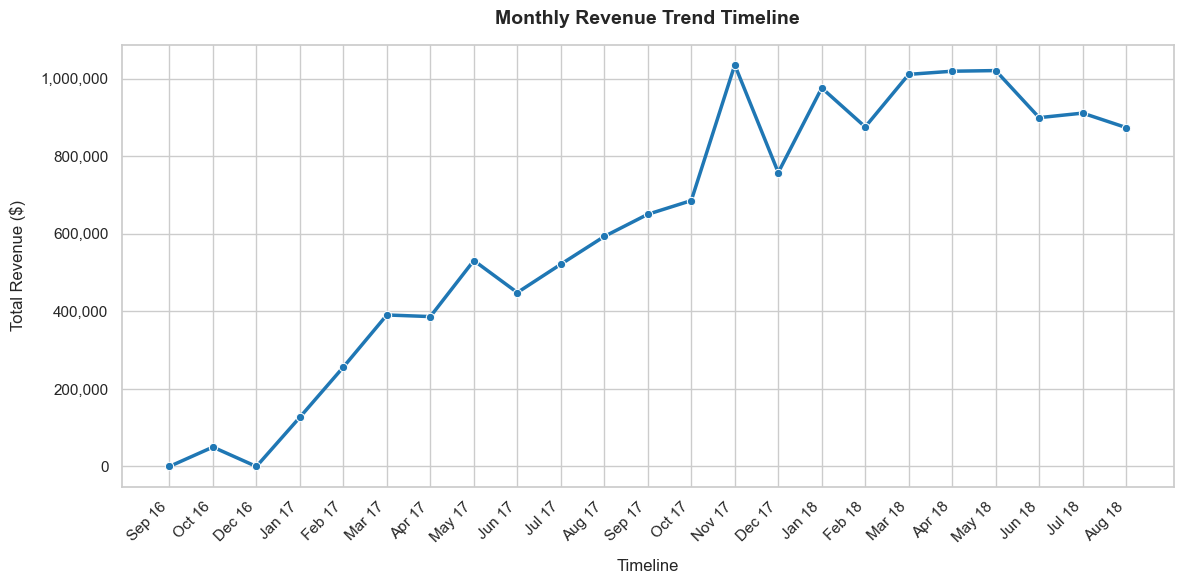

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=filtered_revenue, 
    x='DisplayDate', 
    y='price',      
    marker='o', 
    linewidth=2.5, 
    color='#1f77b4'
)

# Chart styling
plt.title('Monthly Revenue Trend Timeline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')

# Format y-axis numbers with commas (e.g., 50,000)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

Observation

Revenue shows an overall upward trend from early 2017 through mid-2018.

Growth is not perfectly linear; there are a few temporary declines (for example around June 2017 and December 2017), but revenue recovers quickly afterward.

The highest monthly revenue occurs during April–June 2018, where monthly revenue exceeds $1 million.

Revenue remains consistently high throughout most of 2018, suggesting stronger business performance than in 2017.

Business Insight

The business experienced strong and sustained revenue growth over the observed period. After a gradual increase during 2017, monthly revenue stabilized at a significantly higher level throughout 2018. This indicates improvements in customer demand, order volume, or average spending per order. Short-term fluctuations exist but do not change the overall positive trend.

Which calendar months consistently generate the highest revenue across the available years?

In [27]:
sales_ternd.columns

Index(['order_id', 'order_item_id', 'customer_unique_id', 'product_id',
       'seller_id', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'DeliveryDays', 'ProcessingDays',
       'ShippingDays', 'DeliveryDelay', 'order_status', 'price',
       'freight_value', 'payment_value', 'payment_type',
       'payment_installments', 'review_score', 'OrederDate', 'OrderDay',
       'OrderMonth', 'OrderYear', 'QuarterOfOrderDate', 'WeekOfOrder',
       'WeekdayName', 'MonthName', 'is_weekend'],
      dtype='str')

In [28]:
sales_by_month = ( filtered_revenue.groupby('MonthName')['price'].sum().reset_index())

In [29]:
sales_by_month.sort_values('price', ascending=False, inplace=True)

C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\140601862.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


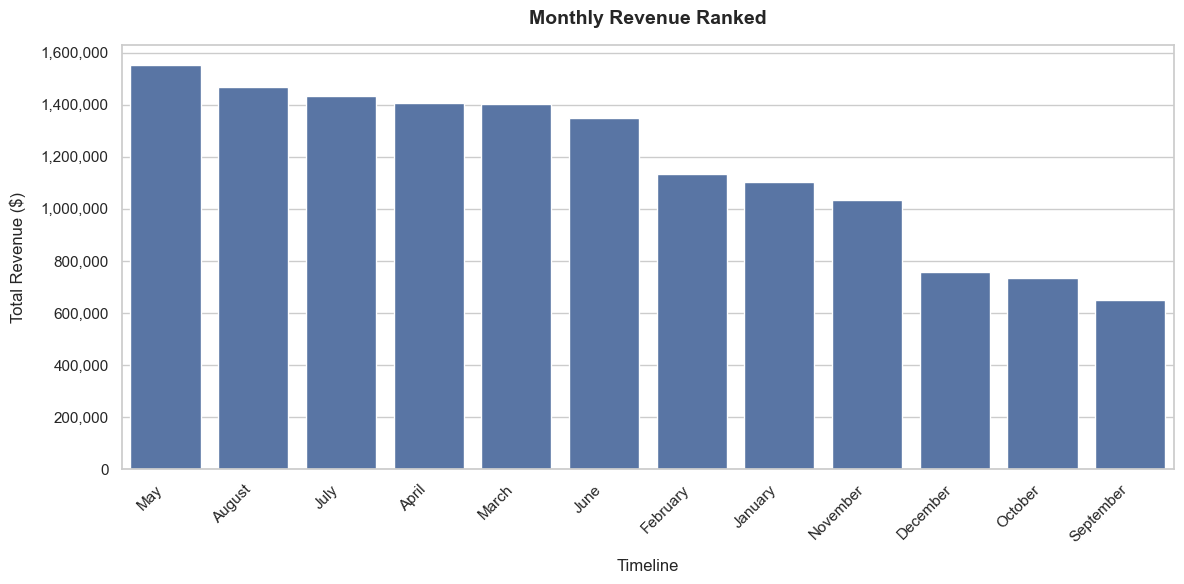

In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=sales_by_month,
    x='MonthName',
    y='price'
)

# Chart styling
plt.title('Monthly Revenue Ranked', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')

# Format y-axis numbers with commas (e.g., 50,000)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

Observation

May generated the highest cumulative revenue, making it the strongest-performing month across all years in the dataset.

August and July followed closely behind, indicating strong sales performance during the mid-year period.

March, April, and June also contributed significantly to overall revenue.

September recorded the lowest cumulative revenue. Since the dataset ends in September 2018

Revenue appears to be stronger during the March–August period compared to the later months of the year.

Business Insight

The business demonstrates a clear seasonal pattern, with the March to August period consistently generating the highest revenue. This suggests that customer demand is stronger during these months, while revenue tends to decline toward the end of the year.

Recommendations

Increase inventory levels before the March–August period to meet anticipated demand.

Allocate a larger portion of marketing and advertising budgets during the highest-performing months to maximize return on investment.

Is the company's revenue concentrated in a few geographic markets, or is it evenly distributed across all states?

In [34]:
sales_trend_customer = sales_ternd.merge(
    customer,
    left_on='customer_unique_id',
    right_on='customer_unique_id',
    how='left'
)

In [35]:
sales_trend_customer.columns

Index(['order_id', 'order_item_id', 'customer_unique_id', 'product_id',
       'seller_id', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'DeliveryDays', 'ProcessingDays',
       'ShippingDays', 'DeliveryDelay', 'order_status', 'price',
       'freight_value', 'payment_value', 'payment_type',
       'payment_installments', 'review_score', 'OrederDate', 'OrderDay',
       'OrderMonth', 'OrderYear', 'QuarterOfOrderDate', 'WeekOfOrder',
       'WeekdayName', 'MonthName', 'is_weekend', 'customer_city',
       'customer_state', 'FirstPurchaseDate', 'LastPurchaseDate',
       'TotalOrders', 'TotalRevenue', 'AverageOrderValue', 'CustomerTenure',
       'DaysFromLastPurchase', 'PurchaseFrquency', 'CustomerStatus',
       'RevenueGroup', 'CustomerTier'],
      dtype='str')

In [36]:
state_revenue = (
    sales_trend_customer.groupby('customer_state')['price']
    .sum()
    .reset_index()
    .sort_values(by='price', ascending=False)
    .reset_index(drop=True)
)

In [37]:
state_revenue['Cumulative_Revenue'] = state_revenue['price'].cumsum()
total_revenue = state_revenue['price'].sum()
state_revenue['Cumulative_Percentage'] = (state_revenue['Cumulative_Revenue'] / total_revenue) * 100

In [38]:
state_revenue.head(5)

,customer_state,price,Cumulative_Revenue,Cumulative_Percentage
0,SP,5.307611e+06,5.307611e+06,37.755299
1,RJ,1.858894e+06,7.166505e+06,50.978405
2,MG,1.600695e+06,8.767200e+06,62.364833
3,RS,7.670918e+05,9.534292e+06,67.821484
4,PR,6.904242e+05,1.022472e+07,72.732766


In [39]:
states_under_80 = state_revenue[state_revenue['Cumulative_Percentage'] <= 80]
# We add 1 to include the state whose boundary officially pushes the total past 80%
num_states_for_80 = len(states_under_80) + 1 

print(f"Executive Summary: Exactly {num_states_for_80} states contribute to 80% of the company's revenue.")

Executive Summary: Exactly 7 states contribute to 80% of the company's revenue.


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\115792096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_revenue, x='customer_state', y='price', ax=ax1, palette='Blues_r')
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\115792096.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(state_revenue['customer_state'], rotation=90, fontsize=9)
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\115792096.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['{:,.0f}'.format(x) for x in ax1.get_yticks()])


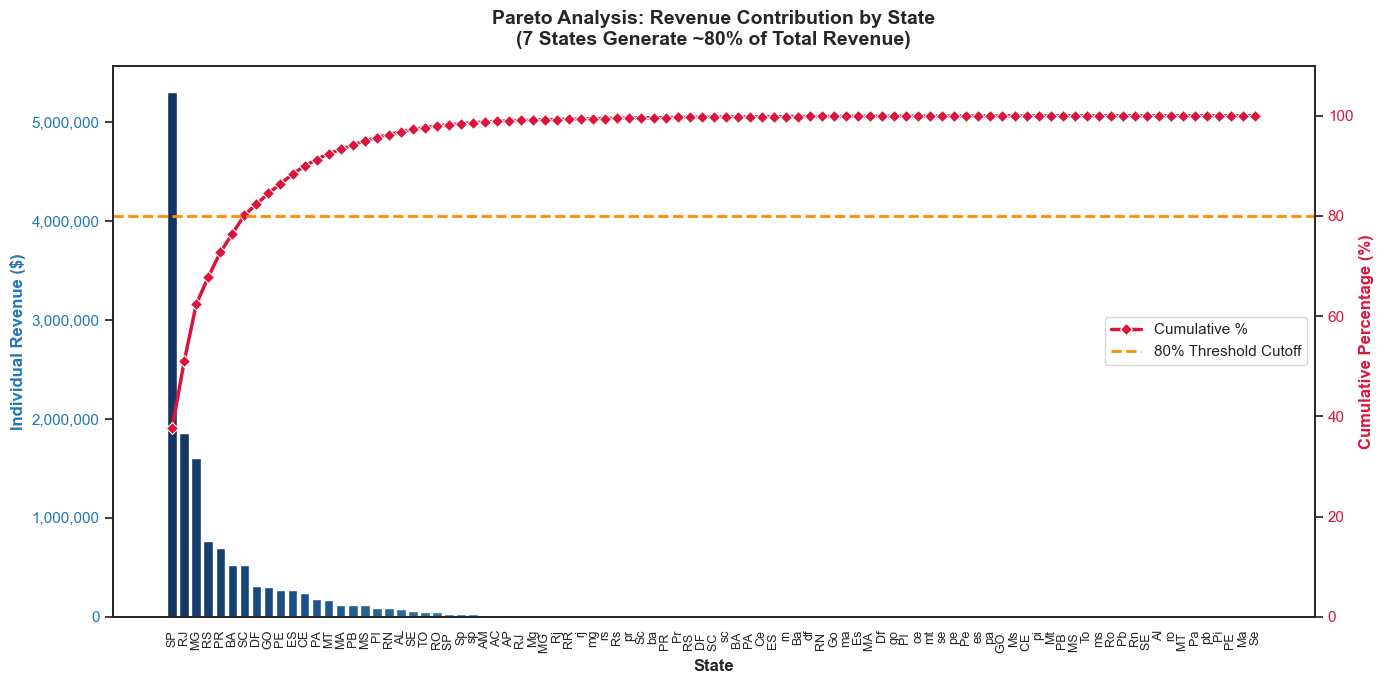

In [40]:
sns.set_theme(style="white")  
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(data=state_revenue, x='customer_state', y='price', ax=ax1, palette='Blues_r')
ax1.set_title(f'Pareto Analysis: Revenue Contribution by State\n({num_states_for_80} States Generate ~80% of Total Revenue)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('State', fontsize=12, fontweight='bold')
ax1.set_ylabel('Individual Revenue ($)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(state_revenue['customer_state'], rotation=90, fontsize=9)

# Format Axis 1 numbers with commas
ax1.set_yticklabels(['{:,.0f}'.format(x) for x in ax1.get_yticks()])

# --- AXIS 2: Twin Axis for the Cumulative % Line ---
ax2 = ax1.twinx()
sns.lineplot(data=state_revenue, x='customer_state', y='Cumulative_Percentage', 
             ax=ax2, color='crimson', marker='D', linewidth=2.5, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)  # Caps percentage layout naturally

# 5. Draw the Executive 80% Threshold Cutoff Line
ax2.axhline(y=80, color='darkorange', linestyle='--', linewidth=2, label='80% Threshold Cutoff')

# Display Legends and adjust layout spacing
ax2.legend(loc='center right')
plt.tight_layout()
plt.show()

Observation

Revenue follows the Pareto Principle, where a relatively small number of states contribute the majority of total revenue.

São Paulo (SP) is the dominant contributor, generating substantially more revenue than any other state.

The cumulative revenue curve reaches approximately 80% after the top 7 states, indicating that only a small subset of states drives most of the company's revenue.

After the seventh state, the cumulative curve begins to flatten, showing that the remaining states individually contribute only a small percentage of total revenue.

Business Insight

The business has a high geographic concentration of revenue. The top seven states account for nearly 80% of total company revenue, with São Paulo alone serving as the primary revenue driver. While this concentration demonstrates strong market penetration in key regions, it also increases business dependence on a limited number of markets.

Recommendations

Continue investing in the top-performing states through customer retention initiatives, localized marketing campaigns, and optimized inventory planning to sustain revenue growth.

Reduce business risk by expanding market presence in lower-contributing states through targeted promotions, partnerships, and improved logistics.

Allocate marketing and operational resources based on revenue contribution to maximize return on investment while pursuing long-term geographic diversification.

Customer Analysis (Marketing Team)

How does revenue contribution differ across equally sized customer segments?

In [41]:
sales_trend_customer.columns

Index(['order_id', 'order_item_id', 'customer_unique_id', 'product_id',
       'seller_id', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'DeliveryDays', 'ProcessingDays',
       'ShippingDays', 'DeliveryDelay', 'order_status', 'price',
       'freight_value', 'payment_value', 'payment_type',
       'payment_installments', 'review_score', 'OrederDate', 'OrderDay',
       'OrderMonth', 'OrderYear', 'QuarterOfOrderDate', 'WeekOfOrder',
       'WeekdayName', 'MonthName', 'is_weekend', 'customer_city',
       'customer_state', 'FirstPurchaseDate', 'LastPurchaseDate',
       'TotalOrders', 'TotalRevenue', 'AverageOrderValue', 'CustomerTenure',
       'DaysFromLastPurchase', 'PurchaseFrquency', 'CustomerStatus',
       'RevenueGroup', 'CustomerTier'],
      dtype='str')

In [42]:
customer_tier_count = (sales_trend_customer.groupby('CustomerTier')['customer_unique_id'].nunique().reset_index())
customer_tier_price = (sales_trend_customer.groupby('CustomerTier')['price'].sum().reset_index())

In [43]:
customer_tier = pd.merge(
    customer_tier_count,
    customer_tier_price,
    on='CustomerTier',
    how='inner'
)

In [44]:
customer_tier

,CustomerTier,customer_unique_id,price
0,Basic,19000,5.237244e+05
1,Bronze,18969,1.073773e+06
2,Gold,18970,2.772959e+06
3,Platinum,18910,7.927600e+06
4,Silver,18953,1.759866e+06


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\546524322.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customer_tier, x='CustomerTier', y='customer_unique_id', ax=ax1, palette='Blues_r')
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\546524322.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['{:,.0f}'.format(x) for x in ax1.get_yticks()])
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\546524322.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['${:,.0f}'.format(x) for x in ax2.get_yticks()])


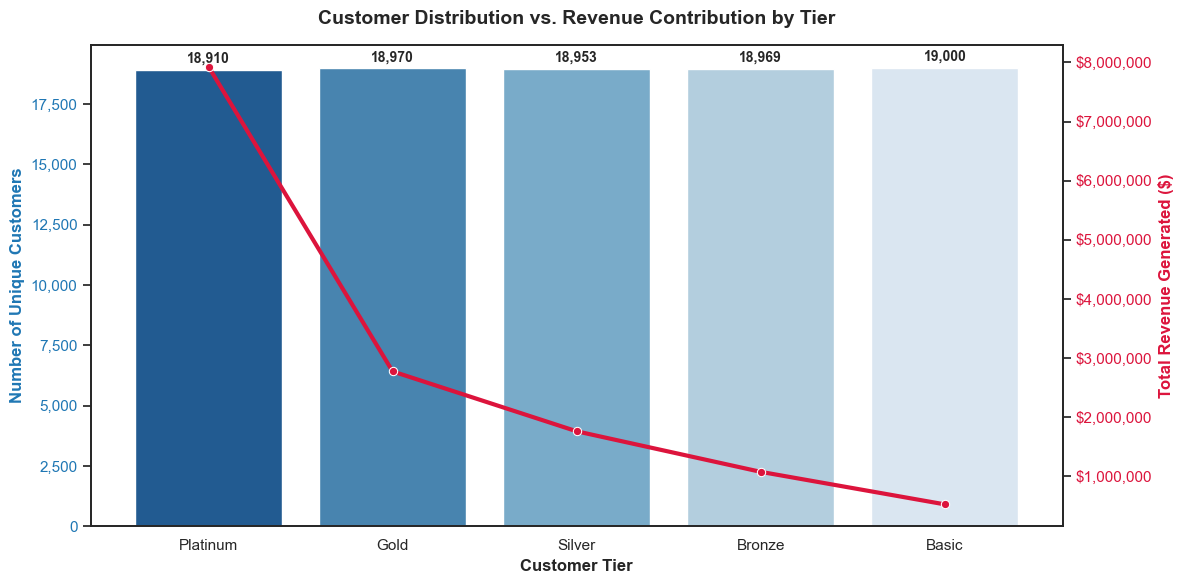

In [45]:
# Ensure a logical order for the tiers
tier_order = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Basic']

# Reorder your summary dataframe to match this layout
customer_tier['CustomerTier'] = pd.Categorical(
    customer_tier['CustomerTier'], categories=tier_order, ordered=True
)
customer_tier = customer_tier.sort_values('CustomerTier')

# Set up the dual-axis figure layout
sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Primary Axis (Left): Bars for Customer Count ---
# Replace 'Unique_Customers' with your exact merged column name
sns.barplot(data=customer_tier, x='CustomerTier', y='customer_unique_id', ax=ax1, palette='Blues_r')
ax1.set_title('Customer Distribution vs. Revenue Contribution by Tier', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Customer Tier', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Unique Customers', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Add values on top of the bars
for container in ax1.containers:
    ax1.bar_label(container, fontsize=10, fontweight='bold', padding=3, fmt='{:,.0f}')

# --- Secondary Axis (Right): Line for Total Revenue ---
ax2 = ax1.twinx()
sns.lineplot(data=customer_tier, x='CustomerTier', y='price', ax=ax2, color='crimson', marker='o', linewidth=3, sort=False)
ax2.set_ylabel('Total Revenue Generated ($)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Clean formatting with commas for both axes
ax1.set_yticklabels(['{:,.0f}'.format(x) for x in ax1.get_yticks()])
ax2.set_yticklabels(['${:,.0f}'.format(x) for x in ax2.get_yticks()])

plt.tight_layout()
plt.show()

Observation

Each customer tier contains approximately 19,000 customers, indicating a balanced segmentation approach.

Platinum customers generate the highest revenue, contributing approximately $8 million, despite representing only one-fifth of the customer base.

Revenue decreases steadily from Platinum → Gold → Silver → Bronze → Basic, forming a clear value hierarchy.

Business Insight

The analysis highlights a substantial difference in customer value, even though each segment contains a similar number of customers. Platinum customers generate several times more revenue than Basic customers, demonstrating that a relatively small group of high-value customers has a disproportionately large impact on overall business performance.

This suggests that revenue growth depends not only on acquiring new customers but also on increasing the value of existing customers and retaining high-value segments.

Recommendations

Prioritize retention programs for Platinum and Gold customers through exclusive benefits, personalized offers, and premium support.

Design targeted campaigns to encourage Silver and Bronze customers to increase their spending and progress to higher-value tiers.

Allocate marketing budgets based on customer value rather than customer count to maximize return on investment.

What is the current distribution of customers across different lifecycle stages (Active, Inactive, and Churn)?

In [46]:
sales_trend_customer.columns

Index(['order_id', 'order_item_id', 'customer_unique_id', 'product_id',
       'seller_id', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'DeliveryDays', 'ProcessingDays',
       'ShippingDays', 'DeliveryDelay', 'order_status', 'price',
       'freight_value', 'payment_value', 'payment_type',
       'payment_installments', 'review_score', 'OrederDate', 'OrderDay',
       'OrderMonth', 'OrderYear', 'QuarterOfOrderDate', 'WeekOfOrder',
       'WeekdayName', 'MonthName', 'is_weekend', 'customer_city',
       'customer_state', 'FirstPurchaseDate', 'LastPurchaseDate',
       'TotalOrders', 'TotalRevenue', 'AverageOrderValue', 'CustomerTenure',
       'DaysFromLastPurchase', 'PurchaseFrquency', 'CustomerStatus',
       'RevenueGroup', 'CustomerTier'],
      dtype='str')

In [47]:
customer_status = (sales_trend_customer.groupby('CustomerStatus')['customer_unique_id'].nunique().reset_index())

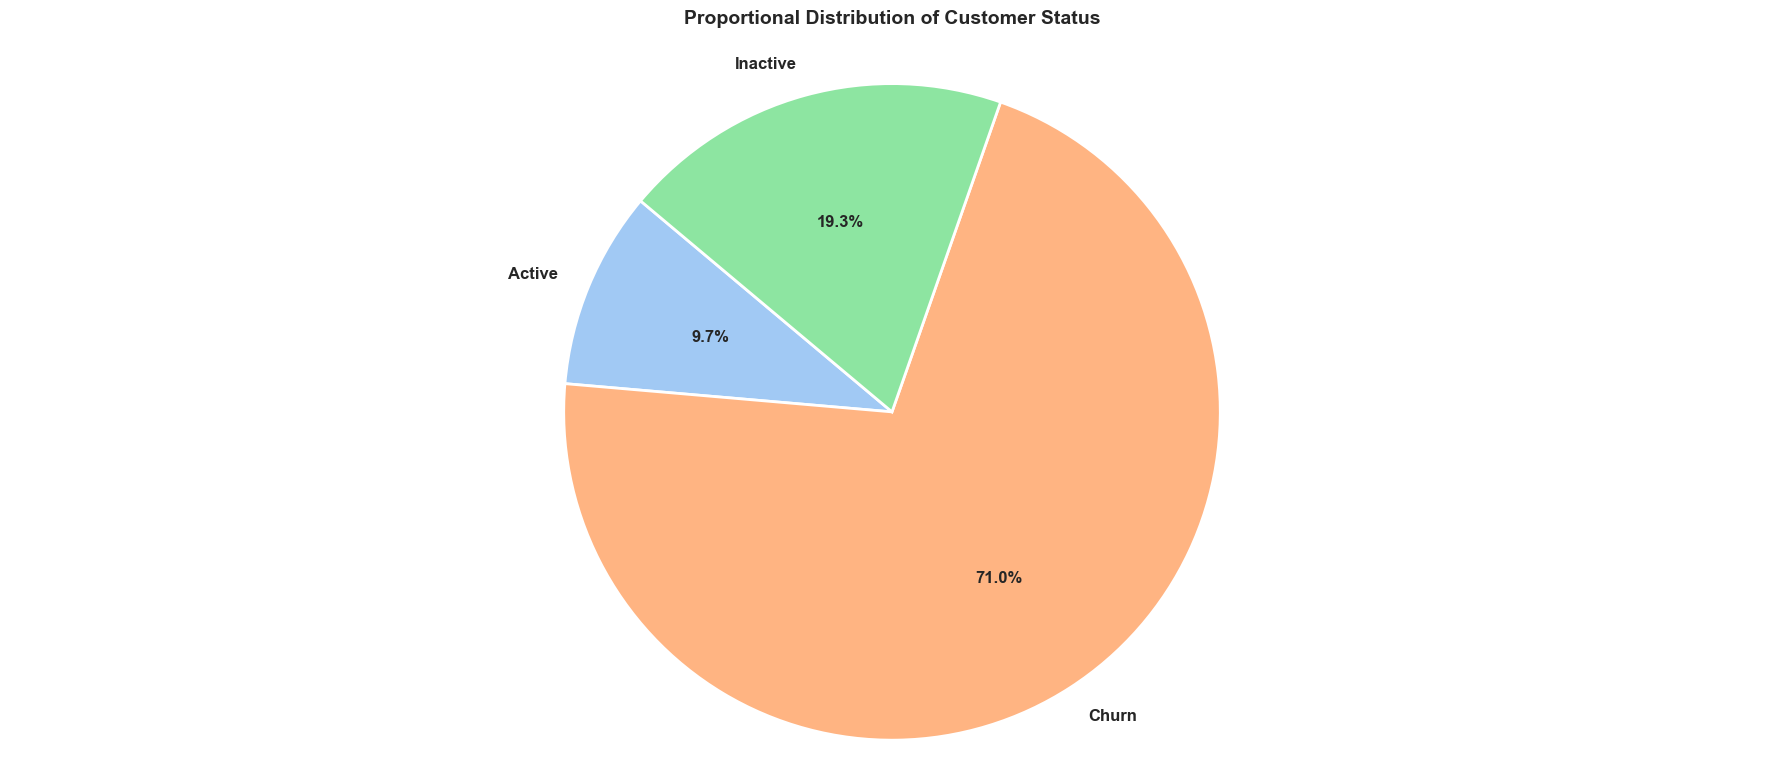

In [48]:
labels = customer_status['CustomerStatus']
sizes = customer_status['customer_unique_id']

colors = sns.color_palette('pastel')[0:len(labels)]

plt.figure(figsize=(18, 8))

plt.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%',       
    startangle=140,          
    textprops={'fontsize': 12, 'fontweight': 'bold'}, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  
)

plt.title('Proportional Distribution of Customer Status', fontsize=14, fontweight='bold', pad=20)

plt.axis('equal')  

plt.tight_layout()
plt.show()

Observation

Approximately 71% of customers are classified as Churned, making it the largest customer segment.

Around 19% of customers are Inactive, indicating they have not purchased recently but may still be recoverable.

Only about 10% of customers remain Active, suggesting a relatively small proportion of customers continue purchasing within the defined active period.

The customer base is heavily weighted toward customers who have stopped purchasing.

Business Insight

The analysis indicates that the business faces a high customer churn rate, with only a small percentage of customers making recent purchases. This suggests that while the company successfully acquires customers, retaining them over time is a significant challenge.

The sizeable inactive segment represents an opportunity for targeted re-engagement campaigns before these customers transition permanently into the churn category.

Recommendations

Launch personalized retention campaigns targeting Inactive customers before they become churned.

Develop loyalty programs and post-purchase engagement strategies to increase repeat purchases among Active customers.

Implement lifecycle marketing initiatives, including email reminders, personalized discounts, and product recommendations, to improve customer retention.

What is the distribution of Customer Tenure?


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\701658872.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}'.format(x) for x in ax.get_yticks()])


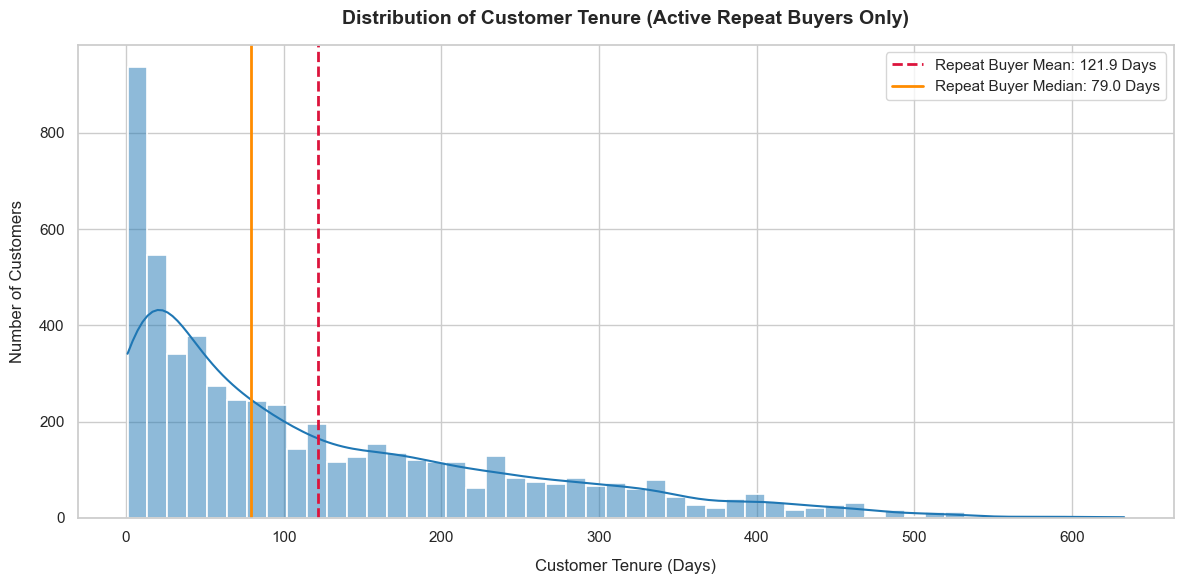

In [49]:
repeat_customers = sales_trend_customer[sales_trend_customer['CustomerTenure'] > 0]

# 2. Set up the visualization style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Plot the histogram for ONLY repeat customers
sns.histplot(
    data=repeat_customers,
    x='CustomerTenure',
    bins=50,             # Increased bins to catch finer granular variations
    kde=True,
    color='#1f77b4',
    edgecolor='white',
    linewidth=1.2,
    ax=ax
)

# 4. Calculate new metrics for repeat buyers
mean_tenure = repeat_customers['CustomerTenure'].mean()
median_tenure = repeat_customers['CustomerTenure'].median()

# 5. Add new vertical reference lines
ax.axvline(mean_tenure, color='crimson', linestyle='--', linewidth=2, 
           label=f'Repeat Buyer Mean: {mean_tenure:.1f} Days')
ax.axvline(median_tenure, color='darkorange', linestyle='-', linewidth=2, 
           label=f'Repeat Buyer Median: {median_tenure:.1f} Days')

# 6. Formatting and Labels
ax.set_title('Distribution of Customer Tenure (Active Repeat Buyers Only)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Tenure (Days)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Customers', fontsize=12, labelpad=10)

# Format the Y-axis counts with commas
ax.set_yticklabels(['{:,.0f}'.format(x) for x in ax.get_yticks()])
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

Observation

The distribution is highly right-skewed, with most repeat customers having relatively short tenures.

The median tenure is approximately 79 days, while the average tenure is around 122 days.

Since the mean is higher than the median, a small number of customers maintain much longer relationships, pulling the average upward.

Only a limited number of customers remain engaged for extended periods, creating a long tail in the distribution.

Business Insight

Most repeat customers make additional purchases within a relatively short period after their first purchase. However, a smaller group of loyal customers continues purchasing over much longer periods, highlighting the presence of a valuable long-term customer segment that significantly contributes to customer lifetime value.

Recommendations

Strengthen post-purchase engagement during the first three months to encourage repeat purchases before customers become inactive.

Develop personalized loyalty programs and targeted promotions aimed at extending customer relationships beyond the typical tenure.

Product Analysis (Product Team)

How do product categories compare in terms of both revenue generation and sales volume?

In [50]:
product.columns

Index(['product_id', 'product_category_name', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'QuanitytSold', 'TotalRevenue', 'RevenueContribution%', 'freight_value',
       'Gross_Sales', 'AveragePrice', 'TotalOrders', 'AverageRating',
       'ReviewCount', 'RevenueRank', 'GrossSalesRank'],
      dtype='str')

In [51]:
product_revenue = (product.groupby('product_category_name')['TotalRevenue']
                       .sum()
                       .reset_index()
                    )

In [52]:
product_sold = (product.groupby('product_category_name')['QuanitytSold']
                       .sum()
                       .reset_index()
                )

In [53]:
product_revenue_sold = pd.merge(
    product_revenue,
    product_sold,
    on='product_category_name',
    how='inner'
) 

In [54]:
top_product_revenue = product_revenue_sold.sort_values(by='TotalRevenue', ascending=False).head(10)

In [55]:
top_product_revenue.head(5)

,product_category_name,TotalRevenue,QuanitytSold
11,beleza_saude,1.239838e+06,9562
66,relogios_presentes,1.183042e+06,5855
13,cama_mesa_banho,1.026585e+06,10997
32,esporte_lazer,9.758397e+05,8546
44,informatica_acessorios,8.952659e+05,7727


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\3649775036.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\3649775036.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_product_revenue['product_category_name'], rotation=45, ha='right', fontsize=10)
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\3649775036.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['${:,.0f}'.format(x) for x in current_revenue_ticks])
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\3649775036.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

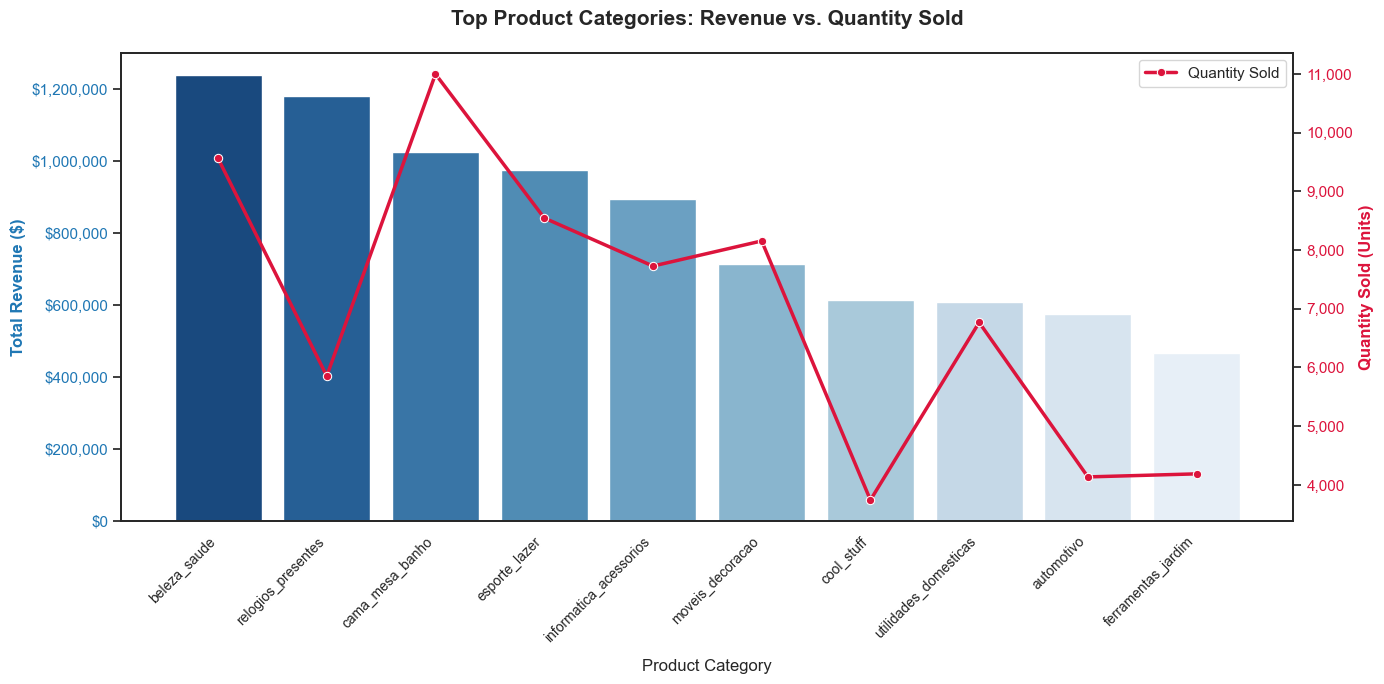

In [56]:
sns.set_theme(style="white") # Keep grid off for clean twinx balancing
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis (Left): Bars for Total Revenue
sns.barplot(
    data=top_product_revenue, 
    x='product_category_name', 
    y='TotalRevenue', 
    ax=ax1, 
    palette='Blues_r'
)
ax1.set_title('Top Product Categories: Revenue vs. Quantity Sold', fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel('Product Category', fontsize=12, labelpad=10)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(top_product_revenue['product_category_name'], rotation=45, ha='right', fontsize=10)

# Format Left Y-Axis as clean currency numbers
current_revenue_ticks = ax1.get_yticks()
ax1.set_yticklabels(['${:,.0f}'.format(x) for x in current_revenue_ticks])

# Secondary Axis (Right): Overlay Line for Quantity Sold
ax2 = ax1.twinx()
sns.lineplot(
    data=top_product_revenue, 
    x='product_category_name', 
    y='QuanitytSold', 
    ax=ax2, 
    color='crimson', 
    marker='o', 
    linewidth=2.5, 
    sort=False,
    label='Quantity Sold'
)
ax2.set_ylabel('Quantity Sold (Units)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Format Right Y-Axis with thousands separators
current_quantity_ticks = ax2.get_yticks()
ax2.set_yticklabels(['{:,.0f}'.format(x) for x in current_quantity_ticks])

# Combine legends cleanly if needed, or rely on color-coded axes
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Observation

Beauty & Health (Beleza Saúde) generates the highest total revenue, despite having only a moderate sales volume compared to several other categories.

Categories such as Cool Stuff, Sports & Leisure, and Unknown have some of the highest quantities sold but generate lower revenue than Beauty & Health.

Computers & Accessories (Informática Acessórios) generates strong revenue even with relatively low sales volume.

Categories like Pet Shop, PCs, and Stationery (Papelaria) record relatively high unit sales but comparatively lower revenue.

Business Insight

The relationship between revenue and quantity sold varies considerably across product categories.

Some categories appear to generate strong revenue with fewer units sold, suggesting a higher average selling price per product. In contrast, other categories rely on selling larger quantities to achieve their revenue, indicating a high-volume sales strategy.

This distinction is important because inventory planning, pricing strategies, and promotional campaigns should differ for premium products versus high-volume products.

Recommendations

Maintain inventory availability for high-revenue categories such as Beauty & Health to prevent stock shortages.

Review pricing and promotional strategies for high-volume but lower-revenue categories to improve revenue per unit sold.

Design different marketing strategies for premium-value categories and volume-driven categories rather than applying the same promotional approach across all products.

Is there a relationship between ratings and revenue?

In [57]:
product_ratings = (product.groupby('product_category_name')['AverageRating']
                       .mean()
                       .reset_index()
                )

In [58]:
total_rating_revenue = pd.merge(
    product_revenue,
    product_ratings,
    on='product_category_name',
    how='inner'
)

In [59]:
total_rating_revenue.head(5)

,product_category_name,TotalRevenue,AverageRating
0,agro_industria_e_comercio,72263.469799,3.814279
1,alimentos,28398.549961,4.163813
2,alimentos_bebidas,15171.570051,4.338169
3,artes,24037.739975,4.229230
4,artes_e_artesanato,1814.010005,4.285904


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\4062211686.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


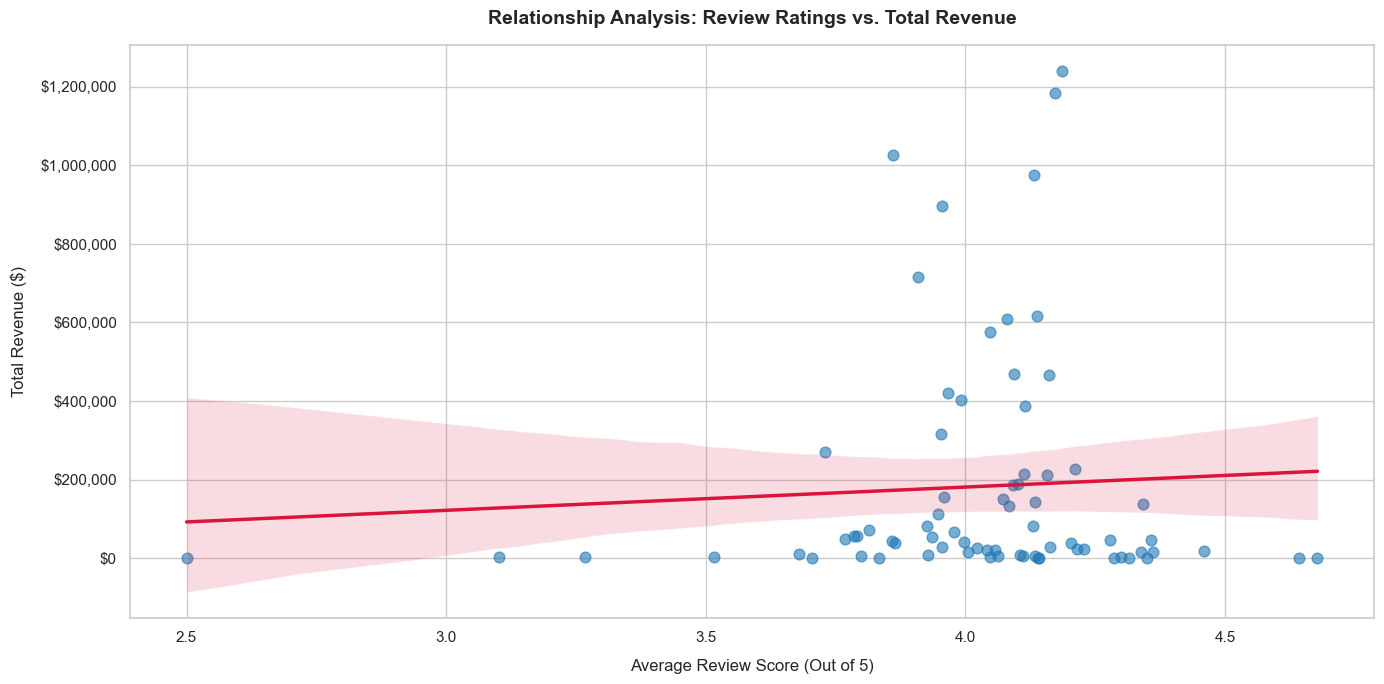

In [60]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Plot Scatter Plot with a Regression (Trend) Line
sns.regplot(
    data=total_rating_revenue,
    x='AverageRating',
    y='TotalRevenue',
    scatter_kws={'alpha':0.6, 'color': '#1f77b4', 's': 60}, # Styles individual dots
    line_kws={'color': 'crimson', 'linewidth': 2.5}         # Styles the trend line
)

# 4. Clean typography and business labels
plt.title('Relationship Analysis: Review Ratings vs. Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Review Score (Out of 5)', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=12, labelpad=10)

# Format Y-axis numbers with commas and dollar signs
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

In [61]:
correlation = total_rating_revenue['AverageRating'].corr(product['TotalRevenue'])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.13


Correlation Analysis: The Pearson correlation coefficient between average review rating and total revenue is 0.13, indicating a weak positive relationship. This confirms that customer ratings have some association with revenue, but they are not the primary driver of product sales.

Observation

Most product categories have an average rating between 3.8 and 4.3, indicating generally positive customer feedback.

The regression line shows a slight positive trend, suggesting that products with higher ratings tend to generate somewhat higher revenue.

However, the data points are widely scattered, with some highly rated categories generating relatively low revenue while others generate exceptionally high revenue.

Several high-revenue categories cluster around ratings of 4.0–4.2, but many categories with similar ratings exhibit much lower revenue.

Business Insight

Although there is a weak positive relationship between product ratings and revenue, customer ratings alone do not explain product sales performance. Other factors—such as pricing, product demand, marketing efforts, inventory availability, and product category—are likely to have a stronger influence on revenue generation.

This indicates that while maintaining high customer satisfaction is important, improving ratings alone is unlikely to guarantee higher sales.

Seller & Operations Analysis

Which sellers generate the highest revenue, and how does their sales volume compare?

In [62]:
seller.columns

Index(['seller_id', 'seller_city', 'seller_state', 'TotalOrders',
       'TotalRevenue', 'TotalProductSold', 'TotalCustomers',
       'AverageDeliveryDays', 'AverageRating', 'RevenueRank'],
      dtype='str')

In [63]:
sorted_seller = seller

In [64]:
sorted_seller = sorted_seller.sort_values(by='TotalRevenue', ascending=False).head(10)

In [65]:
sorted_seller

,seller_id,seller_city,seller_state,TotalOrders,TotalRevenue,TotalProductSold,TotalCustomers,AverageDeliveryDays,AverageRating,RevenueRank
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1124,228071.038353,1148,1116,14.0,4.120309,1
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,356,220740.049545,408,347,13.0,4.056513,2
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1785,200561.421434,1984,1771,14.0,3.815522,3
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,581,192774.429375,582,577,13.0,4.334999,4
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,976,188017.851961,1367,965,22.0,3.385213,5
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,335,176201.879326,339,335,11.0,4.222279,6
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1308,161993.968109,1568,1270,11.0,4.073415,7
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1151,141130.581638,1166,1146,11.0,4.233375,8
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,907,139484.380543,1431,891,11.0,3.844347,9
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1277,133948.810696,1489,1273,10.0,4.059710,10


C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\489568717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\489568717.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sorted_seller['seller_id'], rotation=45, ha='right', fontsize=10)
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\489568717.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(['${:,.0f}'.format(x) for x in current_revenue_ticks])
C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\489568717.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

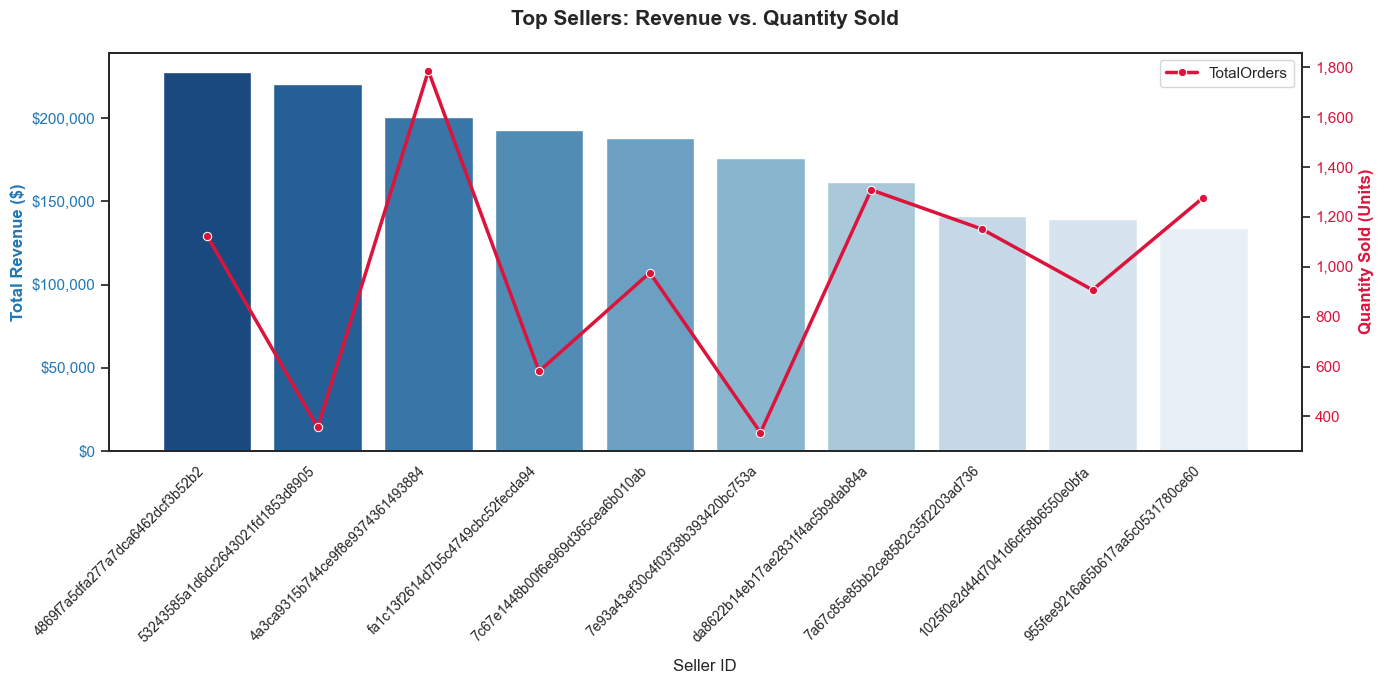

In [66]:
sns.set_theme(style="white") # Keep grid off for clean twinx balancing
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis (Left): Bars for Total Revenue
sns.barplot(
    data=sorted_seller, 
    x='seller_id', 
    y='TotalRevenue', 
    ax=ax1, 
    palette='Blues_r'
)
ax1.set_title('Top Sellers: Revenue vs. Quantity Sold', fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel('Seller ID', fontsize=12, labelpad=10)
ax1.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(sorted_seller['seller_id'], rotation=45, ha='right', fontsize=10)

# Format Left Y-Axis as clean currency numbers
current_revenue_ticks = ax1.get_yticks()
ax1.set_yticklabels(['${:,.0f}'.format(x) for x in current_revenue_ticks])

# Secondary Axis (Right): Overlay Line for Quantity Sold
ax2 = ax1.twinx()
sns.lineplot(
    data=sorted_seller, 
    x='seller_id', 
    y='TotalOrders', 
    ax=ax2, 
    color='crimson', 
    marker='o', 
    linewidth=2.5, 
    sort=False,
    label='TotalOrders'
)
ax2.set_ylabel('Quantity Sold (Units)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Format Right Y-Axis with thousands separators
current_quantity_ticks = ax2.get_yticks()
ax2.set_yticklabels(['{:,.0f}'.format(x) for x in current_quantity_ticks])

# Combine legends cleanly if needed, or rely on color-coded axes
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Observation

The highest-performing seller generated approximately $225K in total revenue.

Revenue among the top 10 sellers is relatively close, ranging from approximately $130K to $225K.

Sales volume varies considerably across sellers. For example, one seller recorded the highest number of orders despite not generating the highest revenue.

Some sellers achieve high revenue with relatively fewer orders, while others depend on larger sales volumes to reach comparable revenue levels.

Business Insight

The comparison reveals that seller performance is driven by different business models.

Some sellers generate strong revenue through higher-value transactions, whereas others rely on higher order volumes. Revenue alone is therefore not sufficient to evaluate seller performance, and both financial contribution and operational volume should be considered when managing seller relationships.

Recommendations

Maintain strong relationships with the highest revenue-generating sellers through partnership programs and performance incentives.

Analyze the selling practices of top-performing sellers and share best practices across the seller network.

Does faster delivery improve customer ratings?

In [72]:
ex_seller = seller[
    ~((seller['AverageDeliveryDays'] == 190))
]

Excluded because it is the only outlier in whole value

C:\Users\Aman\AppData\Local\Temp\ipykernel_43040\1274320486.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


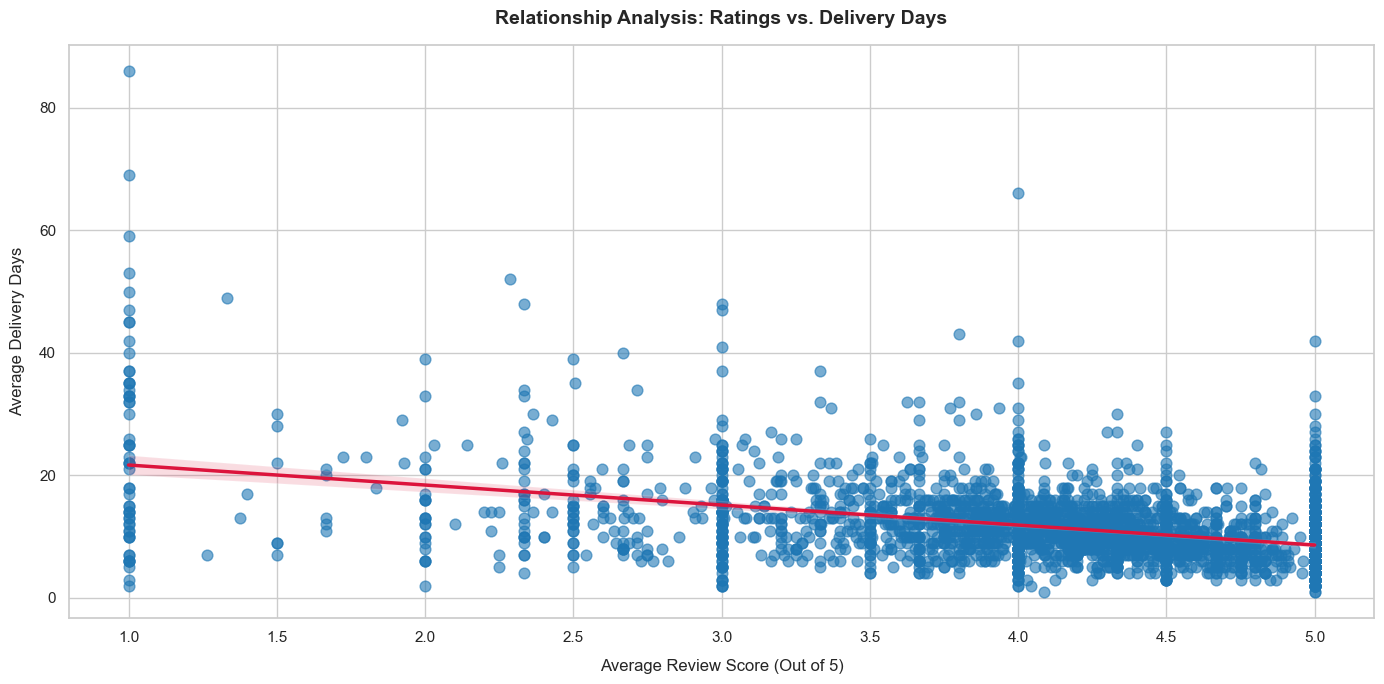

In [75]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Plot Scatter Plot with a Regression (Trend) Line
sns.regplot(
    data=ex_seller,
    x='AverageRating',
    y='AverageDeliveryDays',
    scatter_kws={'alpha':0.6, 'color': '#1f77b4', 's': 60}, # Styles individual dots
    line_kws={'color': 'crimson', 'linewidth': 2.5}         # Styles the trend line
)

# 4. Clean typography and business labels
plt.title('Relationship Analysis: Ratings vs. Delivery Days', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Review Score (Out of 5)', fontsize=12, labelpad=10)
plt.ylabel('Average Delivery Days', fontsize=12, labelpad=10)

# Format Y-axis numbers with commas and dollar signs
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

In [76]:
correlation = ex_seller['AverageRating'].corr(product['TotalRevenue'])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.03


Correlation Analysis: The Pearson correlation coefficient between review ratings and delivery days is 0.03, indicating a moderate positive relationship. This supports the observation that faster deliveries are generally associated with higher customer satisfaction, although other factors also influence customer reviews.

Observation

The scatter plot shows a negative relationship between review ratings and average delivery days.

Customers who gave higher ratings (4–5 stars) generally experienced shorter delivery times, with most deliveries completed within 5–15 days.

Lower-rated reviews (1–2 stars) are associated with a much wider range of delivery times, including several extreme delays exceeding 40–80 days.

The regression line slopes downward, indicating that average delivery time decreases as customer ratings increase.

Despite this trend, there is noticeable variation, suggesting that delivery time is an important—but not the only—factor influencing customer satisfaction.

Business Insight

The analysis suggests that faster deliveries are generally associated with higher customer ratings. Customers receiving orders quickly tend to leave more positive reviews, while prolonged delivery times are more common among lower-rated orders.

However, since some customers still provide high ratings despite longer delivery times (and vice versa), additional factors such as product quality, packaging, pricing, and customer service also contribute to the overall customer experience.

Recommendations

Continue optimizing logistics processes to reduce delivery times, particularly for orders experiencing long shipping delays.

Monitor delivery performance alongside customer ratings to evaluate the impact of logistics initiatives over time.

Proactively communicate expected delivery dates and notify customers of potential delays to manage expectations and improve satisfaction.

Correlation Analysis

Which customer, sales, and operational metrics are most strongly related, and what business insights can be derived from these relationships?

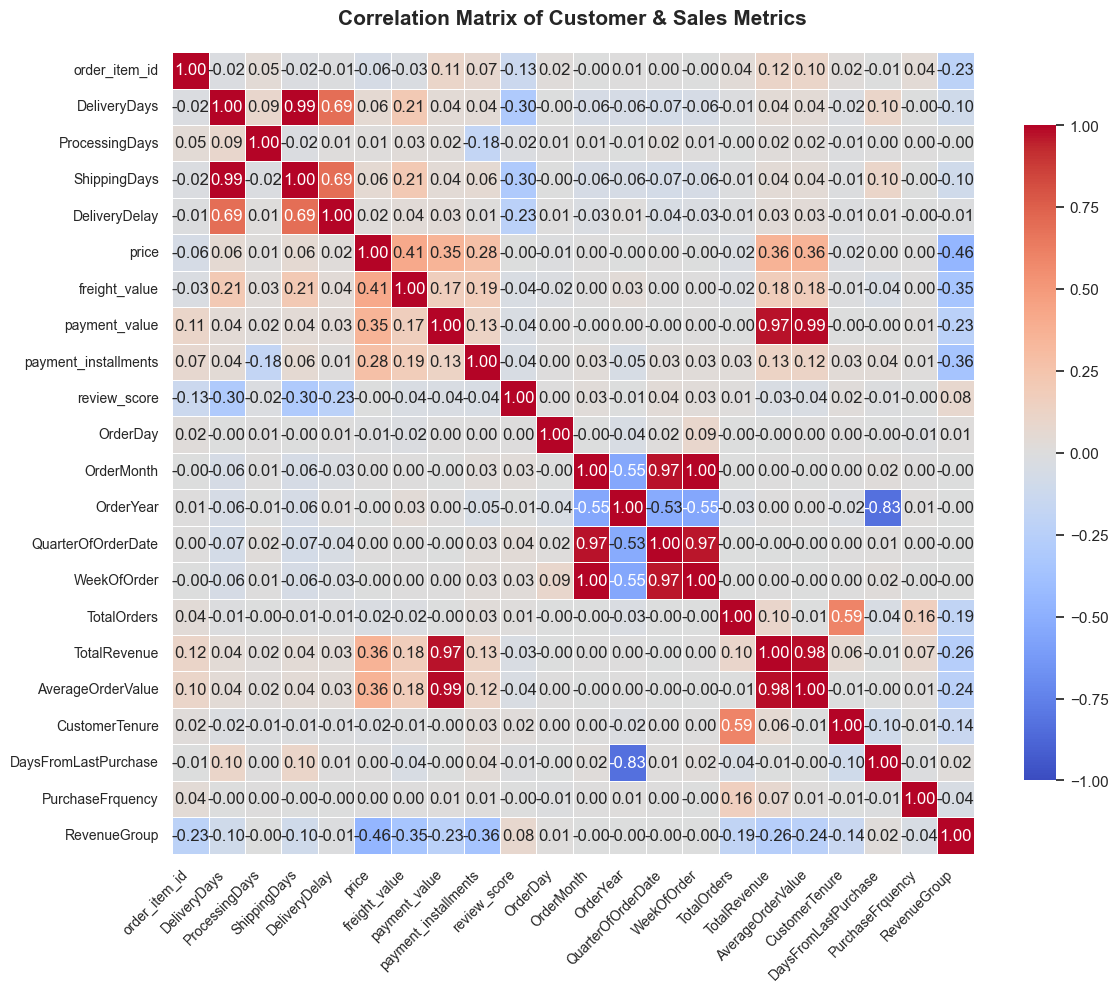

In [77]:
numeric_df = sales_trend_customer.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,           
    fmt=".2f",            
    cmap='coolwarm',        
    vmin=-1, vmax=1,        
    center=0,               
    square=True,         
    linewidths=0.5,        
    cbar_kws={"shrink": .8} 
)

plt.title('Correlation Matrix of Customer & Sales Metrics', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

Key Observations


1. Payment Value ↔ Average Order Value (0.99)

Extremely strong positive correlation.
Larger payments naturally correspond to higher average order values.

Business Insight:
Average Order Value is one of the strongest indicators of total payment received and should be monitored closely when evaluating revenue performance.


2. Payment Value ↔ Total Revenue (0.97)

Very strong positive relationship.

Business Insight:
Revenue growth is primarily driven by increases in customer payments, making payment value a key business KPI.


3. Delivery Days ↔ Shipping Days (0.99)

Nearly perfect positive correlation.

Business Insight:
Overall delivery time is largely determined by shipping duration, suggesting that logistics and transportation efficiency have the greatest impact on delivery performance.


4. Delivery Delay ↔ Delivery Days (0.69)

Strong positive relationship.

Business Insight:
Longer delivery times are associated with greater delivery delays, reinforcing the importance of improving logistics efficiency.


5. Review Score ↔ Delivery Days (-0.30)

Weak-to-moderate negative correlation.

Business Insight:
Customers tend to provide lower ratings when deliveries take longer. While delivery speed affects customer satisfaction, other factors such as product quality and customer service also play important roles.


6. Price ↔ Freight Value (0.41)

Moderate positive relationship.

Business Insight:
Higher-priced products generally incur higher shipping costs, likely due to larger size, weight, or specialized handling requirements.


7. Customer Tenure ↔ Total Orders (0.59)

Moderate positive relationship.

Business Insight:
Customers with longer relationships tend to place more orders, highlighting the importance of customer retention and long-term engagement.


8. Order Month ↔ Quarter (0.97)

Very strong correlation.

Business Insight:
This is expected because quarters are derived directly from months. It confirms the correctness of the feature engineering but does not provide additional business insight.

Recommendations

Focus on increasing Average Order Value through product bundles, cross-selling, and upselling initiatives.

Improve shipping and logistics processes to reduce delivery times and enhance customer satisfaction.

Strengthen customer retention programs to encourage repeat purchases and increase customer lifetime value.

Regularly monitor payment value, delivery performance, and customer engagement as core business KPIs.

Avoid making strategic decisions based solely on weak correlations; combine correlation analysis with deeper investigations where necessary.